### Reconstruct Dense Map with Open3d TSDF

In [4]:
import open3d as o3d
import numpy as np
import cv2
import glob
import os

In [5]:
# -------------------------------
# 1. Load camera intrinsics from TUM YAML using OpenCV
# -------------------------------
def load_camera_params_opencv(yaml_path):
    fs = cv2.FileStorage(yaml_path, cv2.FILE_STORAGE_READ)

    fx = fs.getNode("Camera.fx").real()
    fy = fs.getNode("Camera.fy").real()
    cx = fs.getNode("Camera.cx").real()
    cy = fs.getNode("Camera.cy").real()
    width = int(fs.getNode("Camera.width").real())
    height = int(fs.getNode("Camera.height").real())
    depth_scale = fs.getNode("DepthMapFactor").real()

    fs.release()

    intrinsic = o3d.camera.PinholeCameraIntrinsic(
        width, height, fx, fy, cx, cy
    )

    return intrinsic, depth_scale

# -------------------------------
# 2. Load CameraTrajectory.txt
# -------------------------------
def load_trajectory(path):
    poses = {}
    with open(path, "r") as f:
        for line in f:
            if line.startswith("#"):
                continue
            t, tx, ty, tz, qx, qy, qz, qw = map(float, line.split())
            poses[t] = (np.array([tx, ty, tz]),
                        np.array([qx, qy, qz, qw]))
    return poses

def pose_to_matrix(translation, quat):
    # Open3D expects quaternion in (w, x, y, z) format
    # ORB-SLAM2 quaternion is (qx, qy, qz, qw)
    qx, qy, qz, qw = quat
    quat_o3d = [qw, qx, qy, qz]  # reorder
    T = np.eye(4)
    T[:3, :3] = o3d.geometry.get_rotation_matrix_from_quaternion(quat_o3d)
    T[:3, 3] = translation
    return T

In [9]:
# -------------------------------
# 3. Main
# -------------------------------
if __name__ == "__main__":

    # ===== INPUTS =====
    RGB_DIR = "dataset/rgbd_dataset_freiburg1_room/rgb"          # RGB 이미지 폴더
    DEPTH_DIR = "dataset/rgbd_dataset_freiburg1_room/depth"      # Depth 이미지 폴더
    TRAJ_PATH = "CameraTrajectory.txt"  # ORB-SLAM2 CameraTrajectory
    YAML_PATH = "TUM1.yaml"   # TUM 카메라 YAML

    # Load camera intrinsic & depth scale
    intrinsic, depth_scale = load_camera_params_opencv(YAML_PATH)

    # Load camera poses
    poses = load_trajectory(TRAJ_PATH)

    # Sort images
    rgb_files = sorted(glob.glob(os.path.join(RGB_DIR, "*.png")))
    depth_files = sorted(glob.glob(os.path.join(DEPTH_DIR, "*.png")))

    # Initialize empty point cloud
    pcd_all = o3d.geometry.PointCloud()

    # -------------------------------
    # 4. Frame by frame processing
    # -------------------------------
    for rgb_path, depth_path in zip(rgb_files, depth_files):

        # Extract timestamp from filename
        timestamp = float(os.path.basename(rgb_path).replace(".png", ""))

        if timestamp not in poses:
            continue

        translation, quat = poses[timestamp]
        T_wc = pose_to_matrix(translation, quat)

        # Load RGB-D images
        color = o3d.io.read_image(rgb_path)
        depth = o3d.io.read_image(depth_path)

        rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
            color,
            depth,
            depth_scale=depth_scale,
            depth_trunc=5.0,
            convert_rgb_to_intensity=False
        )

        # Generate point cloud
        pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
            rgbd,
            intrinsic
        )

        # Transform to world coordinate
        pcd.transform(T_wc)
        pcd_all += pcd

    # -------------------------------
    # 5. Post-processing
    # -------------------------------
    pcd_all = pcd_all.voxel_down_sample(voxel_size=0.01)
    pcd_all, _ = pcd_all.remove_statistical_outlier(
        nb_neighbors=20,
        std_ratio=2.0
    )

    # -------------------------------
    # 6. Save & visualize
    # -------------------------------
    o3d.io.write_point_cloud("dense_map.ply", pcd_all)
    o3d.visualization.draw_geometries([pcd_all])

    print("Dense point cloud saved as dense_map.ply")

Dense point cloud saved as dense_map.ply


### Visualize Dense Map

2025-12-21 02:12:38.391 python[16695:11126892] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


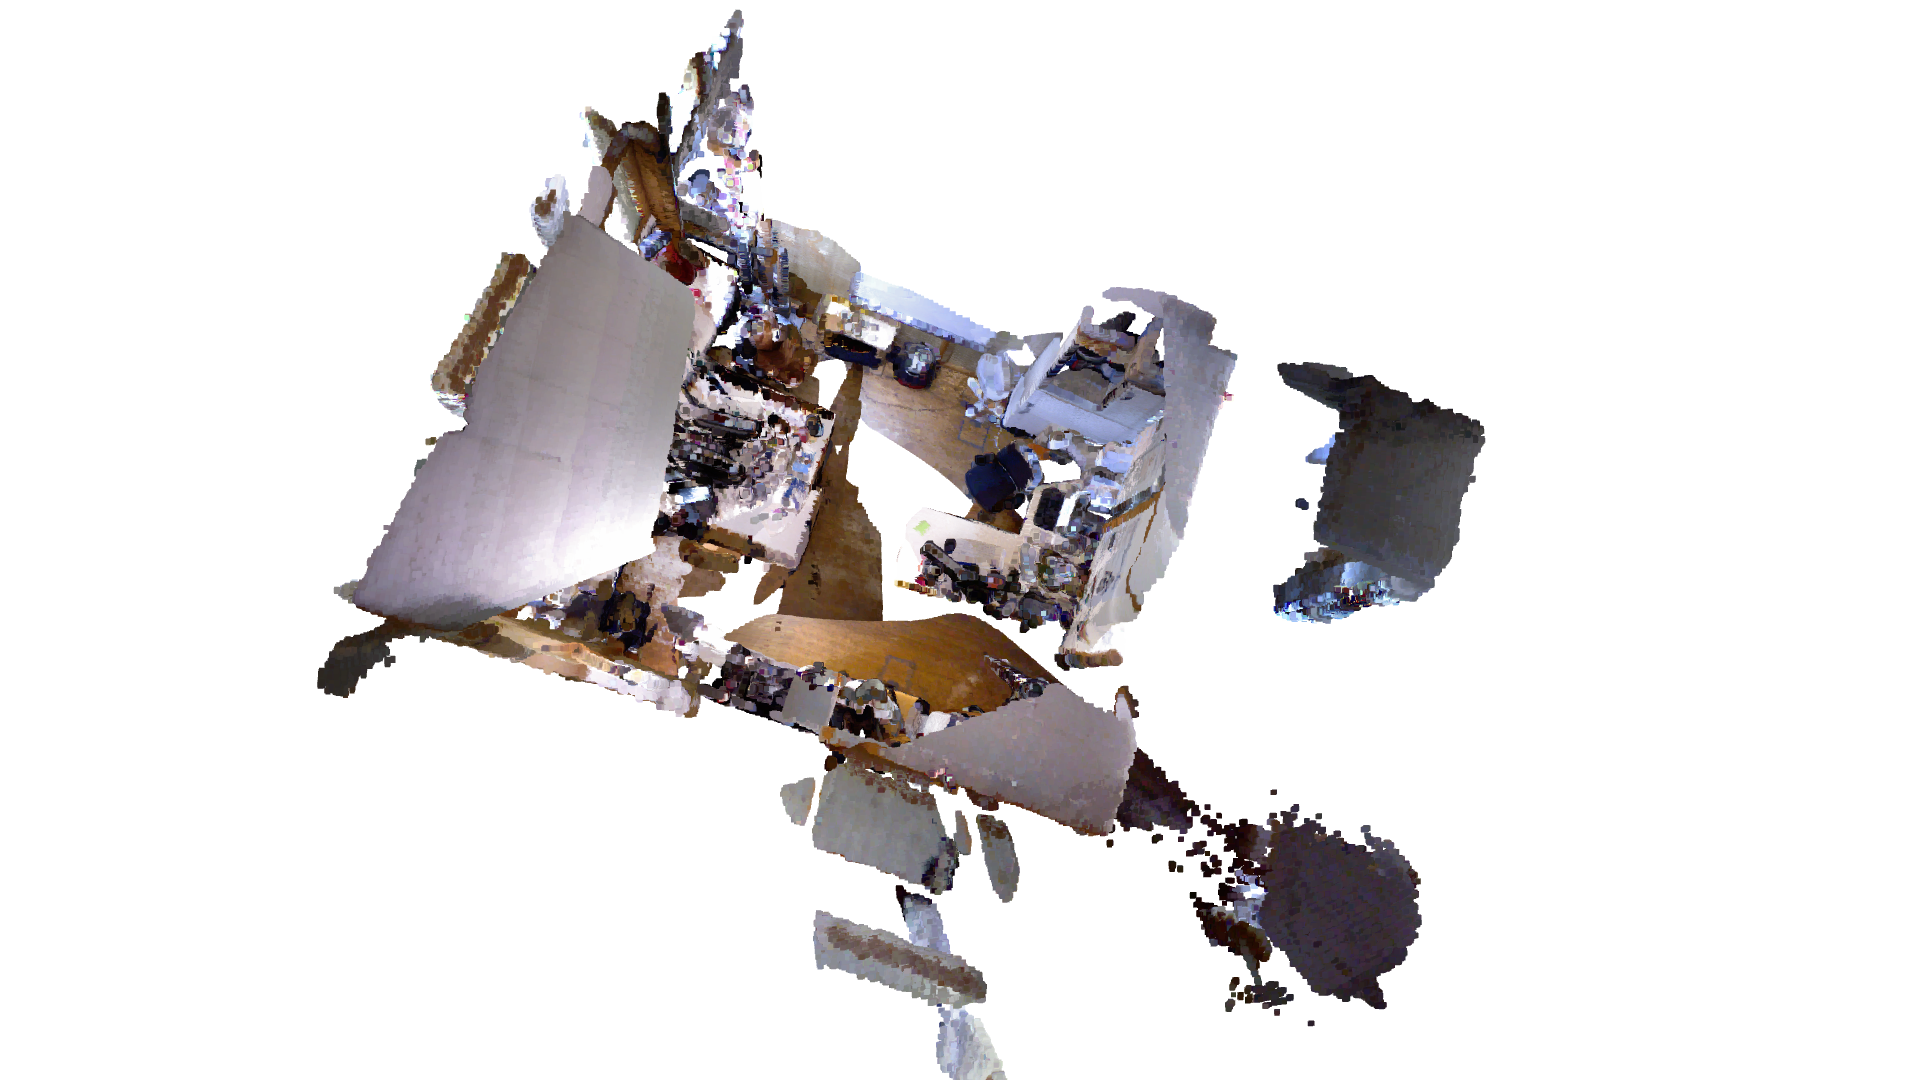

In [1]:
import open3d as o3d
import numpy as np
import os
import sys
import open3d_tutorial as o3dtut

sys.path.append('..')

pcd = o3d.io.read_point_cloud("dense_map.ply")

o3dtut.interactive = not "CI" in os.environ

o3d.visualization.draw_geometries([pcd])